In [159]:
import h5py
import pygmt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [160]:
def to_xarray(data, x, y, key='z'):
    """Converts a 2D numpy array to an xarray.DataArray"""
    return xr.DataArray(data.T, coords=[y, x], dims=[ "lat", "lon"], name=key)

In [161]:
odir = 'OUTPUT_FILES'
with h5py.File(f'{odir}/final_model.h5') as f:
    vs = f['vs'][:]
    # theta = f['theta'][:]
    # g0 = f['G0'][:]
    gc = f['gc'][:]
    gs = f['gs'][:]
with h5py.File(f'{odir}/initial_model.h5') as f:
    init = f['vs'][:]
dv = (vs - init) / init * 100
print(dv.min(), dv.max())

with h5py.File(f'{odir}/target_model.h5') as f:
    tvs = f['vs'][:]
    tgc = f['gc'][:]
    tgs = f['gs'][:]
    # tg0 = f['G0'][:]
    # ttheta = f['theta'][:]
    lon = f['x'][:]
    lat = f['y'][:]
    depths = f['z'][:]
tdv = (tvs - init) / init * 100
lonmin, lonmax = np.min(lon), np.max(lon)
latmin, latmax = np.min(lat), np.max(lat)
print(lonmin, lonmax, latmin, latmax)

-7.162516706790274 6.989302902676606
101.9 104.1 23.9 26.1


In [163]:
tg0 = np.sqrt(tgc**2 + tgs**2)
ttheta = 0.5*np.arctan2(tgs, tgc) / np.pi * 180

fg0 = np.sqrt(gc**2 + gs**2)
ftheta = 0.5*np.arctan2(gs, gc) / np.pi * 180

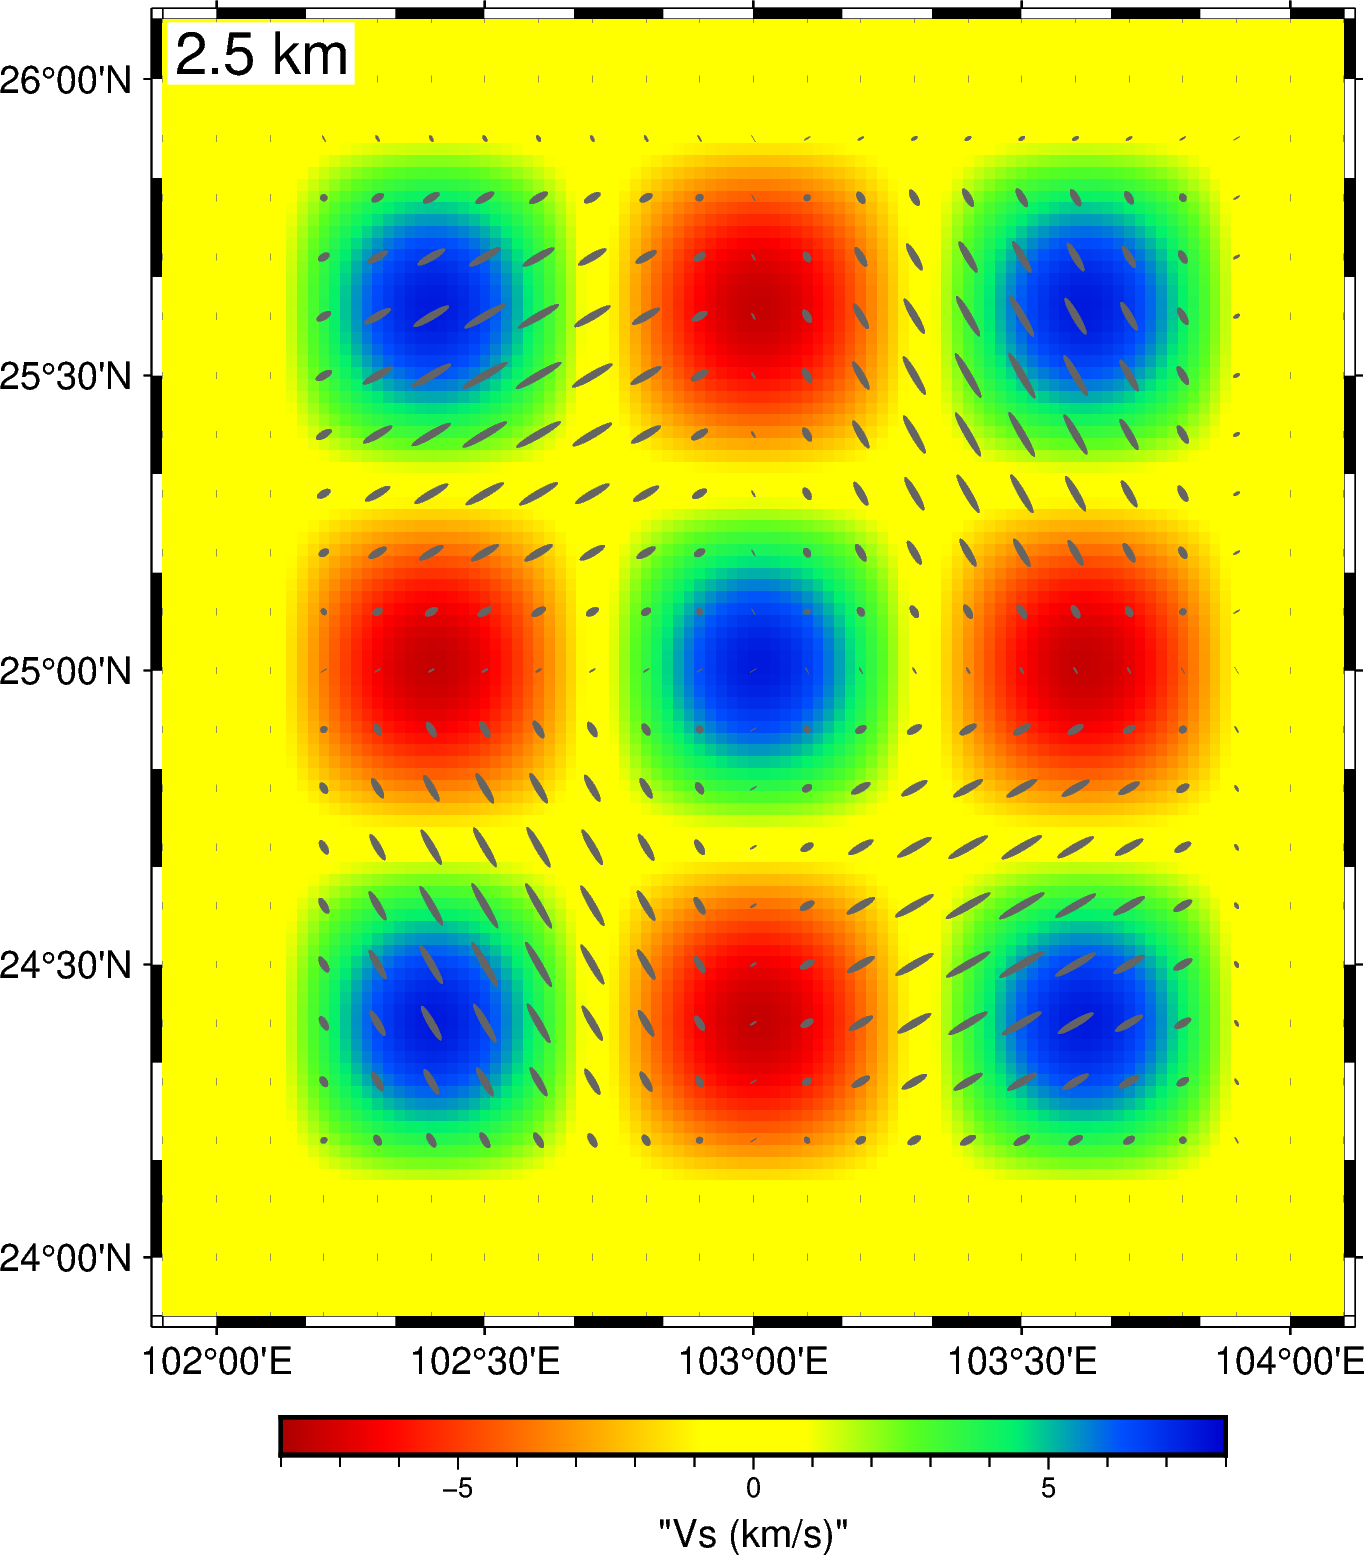

In [168]:
# Plot the true model
dep = 2.5
iz = np.argmin(np.abs(depths-dep))
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(tdv[:,:,int(iz)], lon, lat)
grid_g0 = to_xarray(tg0[:,:,int(iz)], lon, lat)
grid_g0_samp = to_xarray(tg0[::dn,::dn, int(iz)], lon[::dn], lat[::dn])
grid_theta = to_xarray(ttheta[::dn,::dn, int(iz)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*12], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[iz]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+l"Vs (km/s)"')
fig.show()

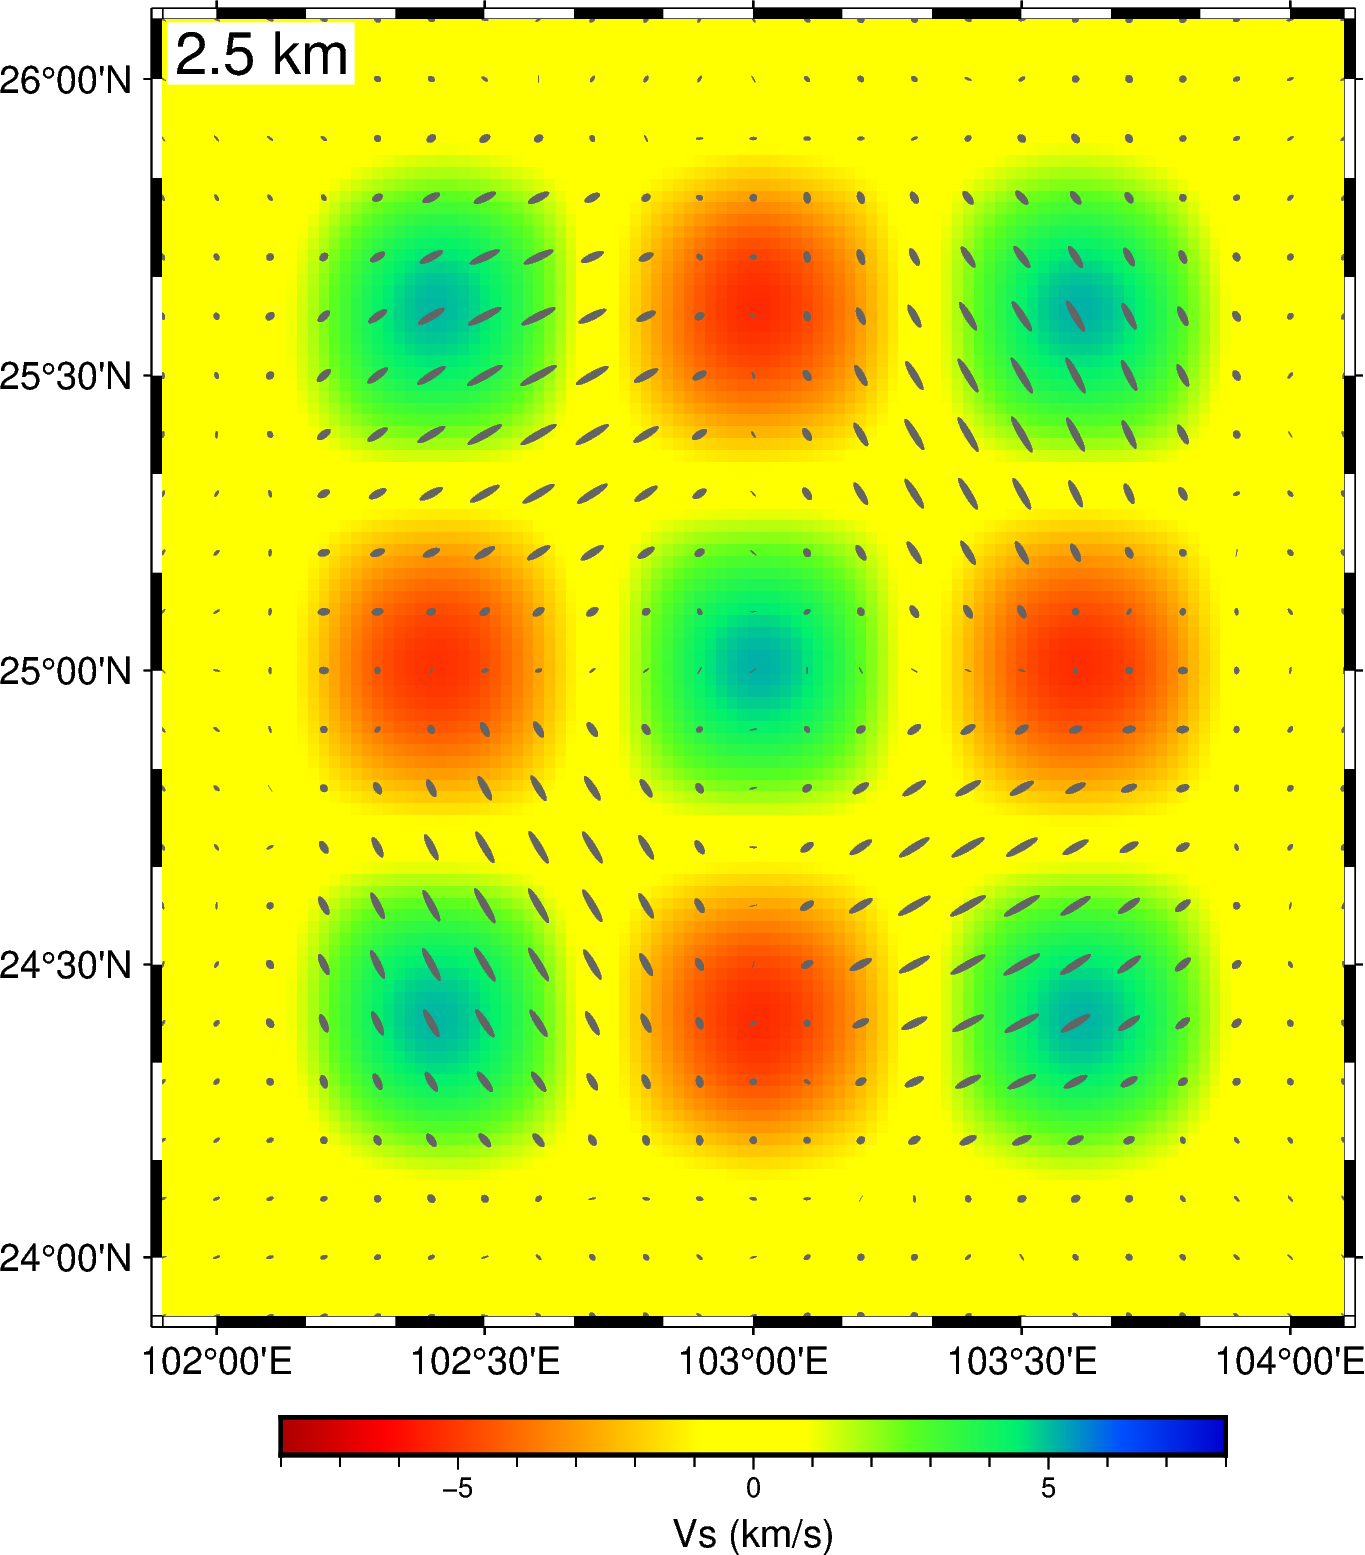

In [167]:
# Plot the inverted model
dep = 5
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(dv[:,:,int(dep)], lon, lat)
grid_g0 = to_xarray(fg0[:,:,int(dep)], lon, lat)
grid_g0_samp = to_xarray(fg0[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
grid_theta = to_xarray(ftheta[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*14], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[dep]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+lVs (km/s)')
fig.show()

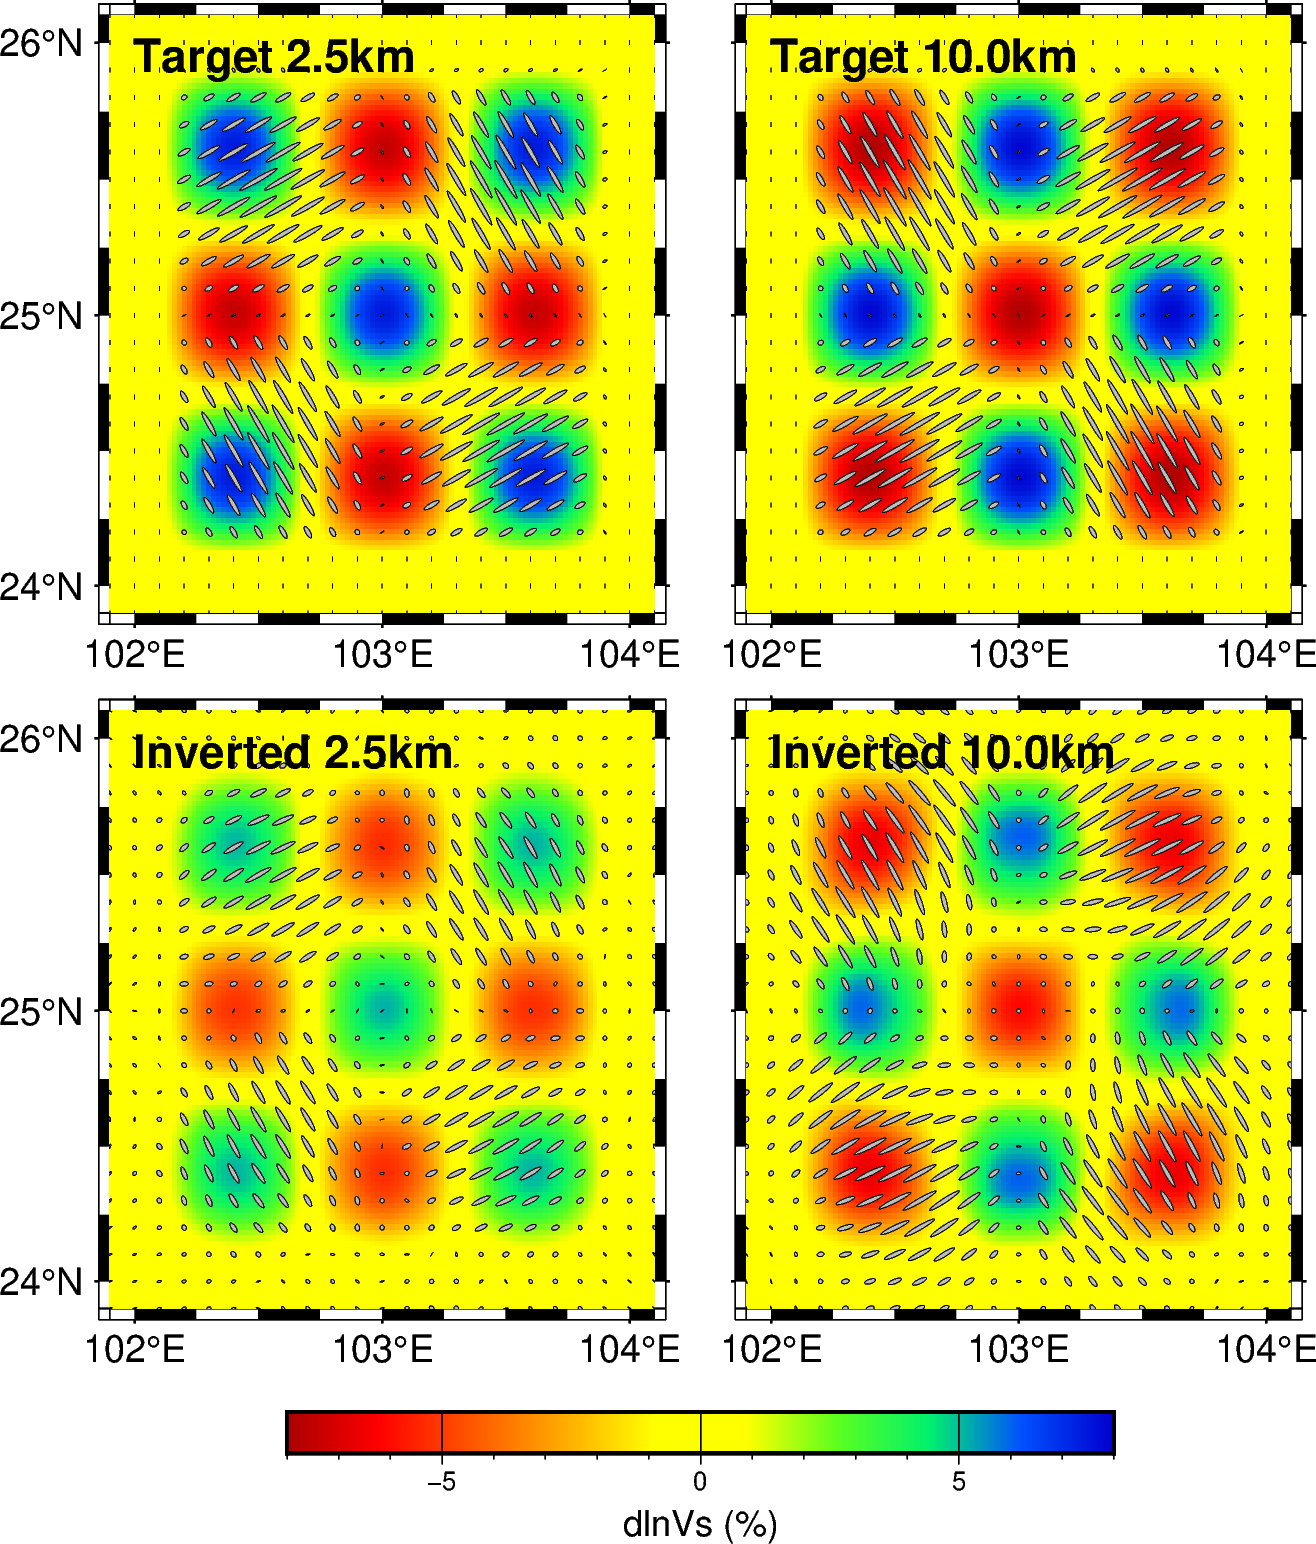

In [197]:
# Side-by-side comparison of target and inverted model at two depths
dep1, dep2 = 2.5, 10
iz1 = np.argmin(np.abs(depths - dep1))
iz2 = np.argmin(np.abs(depths - dep2))
dn = 5
region = [lonmin, lonmax, latmin, latmax]

# Prepare velocity data for both depths and both models
grid_tdv1 = to_xarray(tdv[:, :, int(iz1)], lon, lat)
grid_tdv2 = to_xarray(tdv[:, :, int(iz2)], lon, lat)
grid_dv1 = to_xarray(dv[:, :, int(iz1)], lon, lat)
grid_dv2 = to_xarray(dv[:, :, int(iz2)], lon, lat)

# Prepare anisotropy direction data for both depths and both models
grid_ttheta1 = to_xarray(ttheta[::dn, ::dn, int(iz1)], lon[::dn], lat[::dn])
grid_ttheta2 = to_xarray(ttheta[::dn, ::dn, int(iz2)], lon[::dn], lat[::dn])
grid_ftheta1 = to_xarray(ftheta[::dn, ::dn, int(iz1)], lon[::dn], lat[::dn])
grid_ftheta2 = to_xarray(ftheta[::dn, ::dn, int(iz2)], lon[::dn], lat[::dn])

# Anisotropy amplitude (G0)
grid_tg01 = to_xarray(tg0[::dn, ::dn, int(iz1)], lon[::dn], lat[::dn])
grid_tg02 = to_xarray(tg0[::dn, ::dn, int(iz2)], lon[::dn], lat[::dn])
grid_fg01 = to_xarray(fg0[::dn, ::dn, int(iz1)], lon[::dn], lat[::dn])
grid_fg02 = to_xarray(fg0[::dn, ::dn, int(iz2)], lon[::dn], lat[::dn])

# Convert to xyz format for plotting
xyz_ttheta1 = pygmt.grd2xyz(grid_ttheta1)
xyz_ttheta2 = pygmt.grd2xyz(grid_ttheta2)
xyz_ftheta1 = pygmt.grd2xyz(grid_ftheta1)
xyz_ftheta2 = pygmt.grd2xyz(grid_ftheta2)

xyz_tg01 = pygmt.grd2xyz(grid_tg01)
xyz_tg02 = pygmt.grd2xyz(grid_tg02)
xyz_fg01 = pygmt.grd2xyz(grid_fg01)
xyz_fg02 = pygmt.grd2xyz(grid_fg02)

# Combine theta and amplitude for anisotropy ellipse plotting
ani_t1 = pd.concat([xyz_ttheta1['lon'], xyz_ttheta1['lat'], xyz_ttheta1['z'], xyz_tg01['z']*10], axis=1)
ani_t1['minax'] = np.ones_like(ani_t1['lon'])*0.04
ani_t2 = pd.concat([xyz_ttheta2['lon'], xyz_ttheta2['lat'], xyz_ttheta2['z'], xyz_tg02['z']*10], axis=1)
ani_t2['minax'] = np.ones_like(ani_t2['lon'])*0.04

ani_f1 = pd.concat([xyz_ftheta1['lon'], xyz_ftheta1['lat'], xyz_ftheta1['z'], xyz_fg01['z']*10], axis=1)
ani_f1['minax'] = np.ones_like(ani_f1['lon'])*0.04
ani_f2 = pd.concat([xyz_ftheta2['lon'], xyz_ftheta2['lat'], xyz_ftheta2['z'], xyz_fg02['z']*10], axis=1)
ani_f2['minax'] = np.ones_like(ani_f2['lon'])*0.04

# Create a figure with 2x2 subplots
fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=2, figsize=(10, 11)):
    pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)

    # Row 1: Target model at dep1 and dep2
    with fig.set_panel(panel=0):
        fig.basemap(region=region, projection='M?', frame='WeSn')
        fig.grdimage(grid_tdv1, cmap=True)
        fig.plot(ani_t1, style='e', fill='gray', pen='0.1p,black')
        fig.text(text=f'Target {depths[iz1]:.1f}km', x=region[0], y=region[3], font='11p,Helvetica-Bold', justify='TL', offset='0.2c/-0.2c')
    
    with fig.set_panel(panel=1):
        fig.basemap(region=region, projection='M?', frame='weSn')
        fig.grdimage(grid_tdv2, cmap=True)
        fig.plot(ani_t2, style='e', fill='gray', pen='0.1p,black')
        fig.text(text=f'Target {depths[iz2]:.1f}km', x=region[0], y=region[3], font='11p,Helvetica-Bold', justify='TL', offset='0.2c/-0.2c')
    
    # Row 2: Inverted model at dep1 and dep2
    with fig.set_panel(panel=2):
        fig.basemap(region=region, projection='M?', frame='WeSn')
        fig.grdimage(grid_dv1, cmap=True)
        fig.plot(ani_f1, style='e', fill='gray', pen='0.1p,black')
        fig.text(text=f'Inverted {depths[iz1]:.1f}km', x=region[0], y=region[3], font='11p,Helvetica-Bold', justify='TL', offset='0.2c/-0.2c')
    
    with fig.set_panel(panel=3):
        fig.basemap(region=region, projection='M?', frame='weSn')
        fig.grdimage(grid_dv2, cmap=True)
        fig.plot(ani_f2, style='e', fill='gray', pen='0.1p,black')
        fig.text(text=f'Inverted {depths[iz2]:.1f}km', x=region[0], y=region[3], font='11p,Helvetica-Bold', justify='TL', offset='0.2c/-0.2c')

# Add single colorbar at the bottom
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.colorbar(frame='afg+ldlnVs (%)', position='jBC+w7c/0.35c+h+m+o0c/-1.2c')
fig.show()

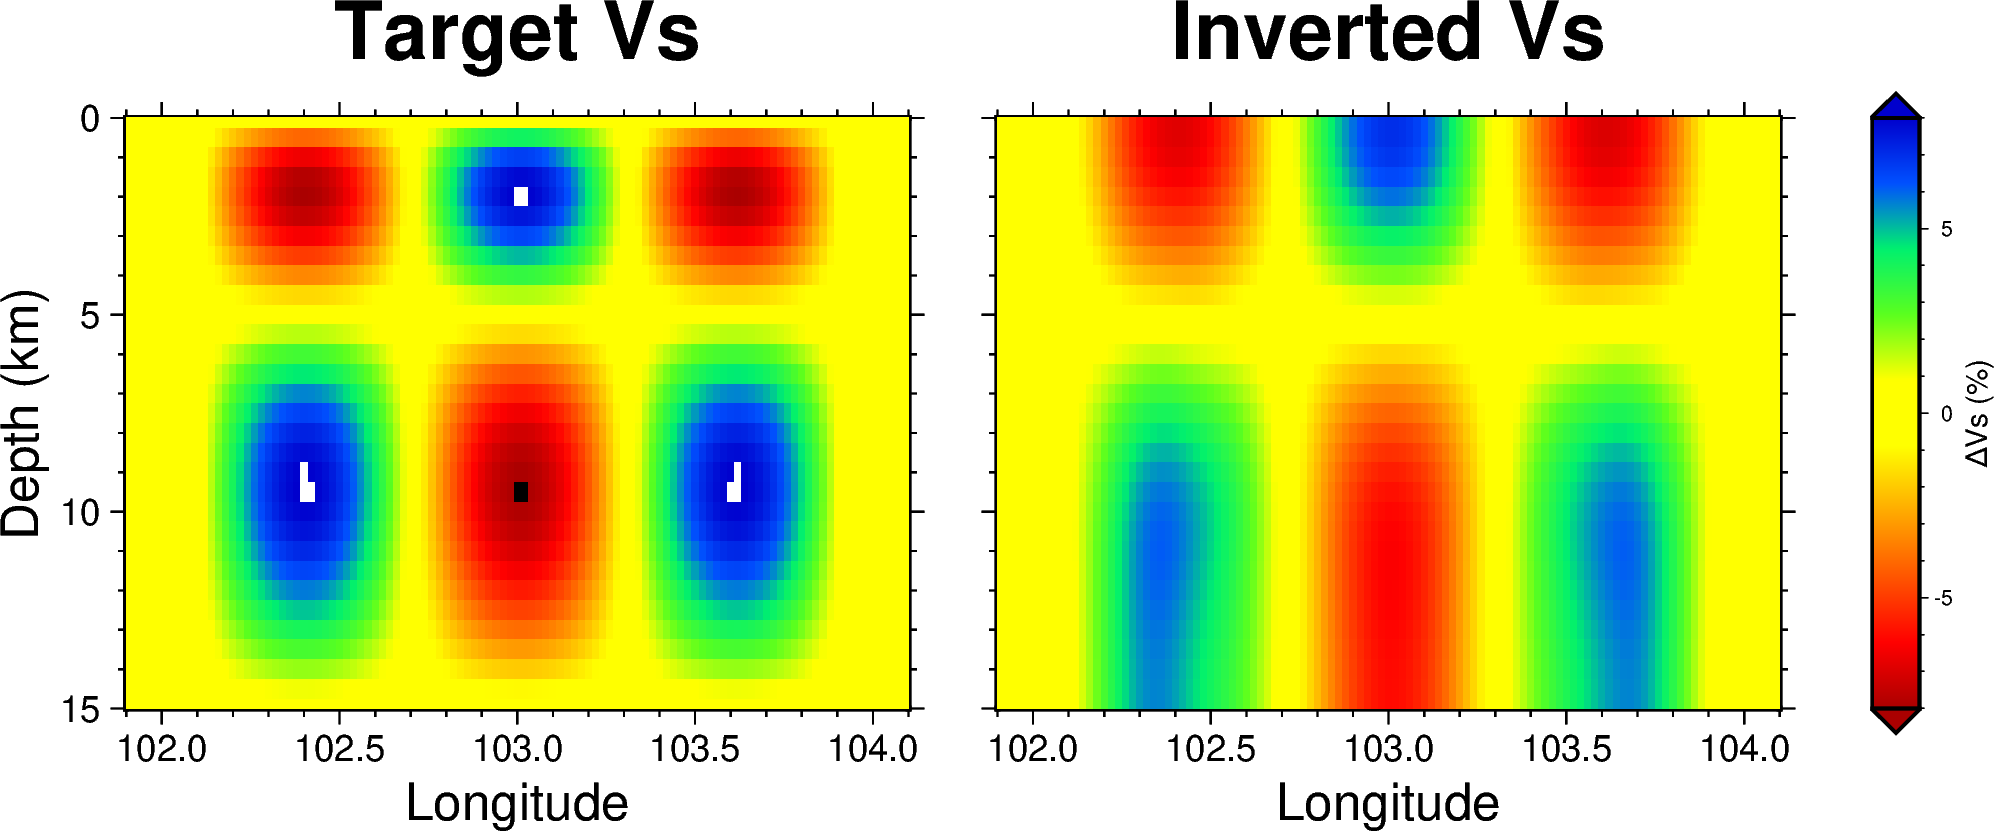

In [215]:
# Velocity cross-sections (lon-depth profile at middle latitude)
iy = len(lat) // 2  # Middle latitude

# Extract cross-section data
section_tvs = tdv[:, iy, :]  # Target velocity (nlon, ndepth)
section_dvs = dv[:, iy, :]   # Inverted velocity change (nlon, ndepth)

# Convert to xarray.DataArray for pygmt
grid_tvs_section = xr.DataArray(section_tvs.T, coords=[depths, lon], dims=['z', 'lon'], name='vs')
grid_dvs_section = xr.DataArray(section_dvs.T, coords=[depths, lon], dims=['z', 'lon'], name='dv')

# Create cross-section figure with 1x2 subplots
fig = pygmt.Figure()
with fig.subplot(nrows=1, ncols=2, figsize=(14, 5)):
    pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], background=True, continuous=True)
    # Plot target model cross-section
    with fig.set_panel(panel=0):
        pygmt.makecpt(cmap='seis', series=[section_tvs.min(), section_tvs.max(), 0.1], continuous=True)
        fig.basemap(region=[lonmin, lonmax, depths.min(), depths.max()], projection='X7c/-?c', frame=['WeSn+tTarget Vs', 'x+lLongitude', 'y+lDepth (km)'])
        fig.grdimage(grid_tvs_section, cmap=True)
    
    # Plot inverted model cross-section
    with fig.set_panel(panel=1):
        # pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
        fig.basemap(region=[lonmin, lonmax, depths.min(), depths.max()], projection='X7c/-?c', frame=['weSn+tInverted Vs', 'x+lLongitude', 'y+lDepth (km)'])
        fig.grdimage(grid_dvs_section, cmap=True)
        fig.colorbar(frame='af+lΔVs (%)', position='JMR+w5c/0.4c+e')

fig.show()